In [1]:
import pandas as pd

In [2]:
survey_data = "Recommersion_28 febbraio 2025_14.21.csv"

In [3]:
df = pd.read_csv(survey_data).drop([0,1])
df

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,Custom_Cosine2_2,Custom_Cosine2_3,Custom_Cosine2_4,Custom_Cosine2_5,Diff_cust_cos2_1,Diff_cust_cos2_2,Emotion Type,Perception,Recommersion_utility,Description_utility
2,2025-02-22 11:41:32,2025-02-22 12:51:32,Indirizzo IP,109.118.32.194,100,4199,Vero,2025-02-22 12:51:32,R_88HfxgPxGURrICl,NaN,...,2,2,1,0,-0.076,0.146,NaN,Ritmo; Tempo; Timbrica strumentale,Molto utile,Capire in modo quasi chiaro ciò che vorrei asc...
3,2025-02-22 19:56:57,2025-02-22 20:31:09,Indirizzo IP,93.40.216.67,100,2051,Vero,2025-02-22 20:31:09,R_20ulSvJAPBNi7bH,NaN,...,2,1,0,2,-0.096,-0.006,Felice,Ritmo; Testo (capito),Moderatamente utile,Velocità nell’ottenere playlist in base alla t...
4,2025-02-23 14:53:27,2025-02-23 16:00:26,Indirizzo IP,109.118.44.21,100,4018,Vero,2025-02-23 16:00:27,R_8HBSPCfnNAk4azc,NaN,...,1,2,2,1,-0.096,0,Eccitazione,Ritmo; Timbrica generale e vocale;,Moderatamente utile,Utile musicalmente ma poco a livello musico/te...
5,2025-02-23 17:01:51,2025-02-23 18:17:15,Indirizzo IP,109.118.33.113,100,4523,Vero,2025-02-23 18:17:15,R_2D8cruL7Cnt5enW,NaN,...,1,1,1,2,-0.223,0.146,Rilassata,"Ritmo, tono voce; BPM",Molto utile,Interpreta un’emozione sul momento risolvendo ...
6,2025-02-23 21:44:21,2025-02-23 22:19:00,Indirizzo IP,109.118.33.113,100,2078,Vero,2025-02-23 22:19:00,R_2cYBnJiS4kcJo0g,NaN,...,0,1,0,1,-0.197,0.025,Stanchezza moderata,Tipo di suoni; Ritmo,Moderatamente utile,L’importanza di consigliare musica in modo mol...
7,2025-02-24 15:33:26,2025-02-24 16:26:59,Indirizzo IP,109.118.47.116,100,3213,Vero,2025-02-24 16:27:00,R_2ZNR4ZjiC0bBwRA,NaN,...,1,2,0,1,-0.07,-0.019,Spensierata,Ritmo; Analogia di una situazione reale,Estremamente utile,Attualità come comando vocale; Sicurezza e rap...
8,2025-02-25 14:21:59,2025-02-25 18:06:15,Anteprima sondaggio,NaN,100,13456,Vero,2025-02-25 18:06:16,R_8EhNOnZGKAgoRXj,NaN,...,2,2,3,0,-0.107,0.161,Frustrata,genere musicale; sonorità; ritmo.,Molto utile,L'immediatezza nel capire cosa si vuole ascolt...
9,2025-02-25 18:07:13,2025-02-25 19:21:13,Anteprima sondaggio,NaN,100,4440,Vero,2025-02-25 19:21:14,R_8Pu5xW4gsneFAew,NaN,...,1,1,1,1,-0.279,0.231,Annoiata,Ritmo; Intensità sonora; timbrica specialmente...,Molto utile,Utile per scoperta e personalizzazione dei brani
10,2025-02-26 11:24:31,2025-02-26 11:52:31,Anteprima sondaggio,NaN,100,1679,Vero,2025-02-26 11:52:31,R_8dcZ4pGqBEreIDX,NaN,...,1,0,2,1,-0.131,-0.097,Felice,Ritmo; Timbro vocale,Estremamente utile,Velocità nel ricercare nuovi brani basati sul ...
11,2025-02-26 14:46:11,2025-02-26 15:15:07,Anteprima sondaggio,NaN,100,1735,Vero,2025-02-26 15:15:07,R_8Hk3n2wN8tBvzmn,NaN,...,3,1,0,0,-0.086,0.214,Sollevato,Ritmo; Armonia; Modo,Molto utile,Ricercare ed ascoltare brani adatti al proprio...


Metrics:
- Mean Average Precision
- Mean Reciprocal Rank
- Normalized Discounted Cumulative Gain

Metrics for these specifics:
- Audeering Euclidean
- Audeering Cosine
- Custom Euclidean
- Custom Cosine


In [4]:
import numpy as np
import math

emotion_number = 1
cut = 5
relevance = [2, 3]


def calculate_map(model, spotify=False):
    emotion = 2 if spotify else 1

    def average_precision(user_idx):
        ap_list = [
            i + 1 for i in range(cut) 
            if int(df[f"{model}{emotion}_{i+1}"].iloc[user_idx]) in relevance
        ]
        return np.mean([(rel+1) / i for rel, i in enumerate(ap_list)]) if ap_list else 0

    return np.mean(list(map(average_precision, range(len(df)))))


def calculate_ndcg(model, spotify=False):
    def calculate_dcg(index, value):
        return (2**int(value) - 1) / math.log2(index + 2)

    def compute_ndcg_emotion(user):
        emotion = 2 if spotify else 1
        dcg_values = [df[f"{model}{emotion}_{i+1}"].iloc[user] for i in range(cut)]
        idcg_values = sorted(dcg_values, reverse=True)
        dcg = sum(map(calculate_dcg, range(len(dcg_values)), dcg_values))
        idcg = sum(map(calculate_dcg, range(len(idcg_values)), idcg_values))
        return dcg / idcg if idcg > 0 else 0

    ndcg_values = map(compute_ndcg_emotion, range(len(df)))
    return np.mean(list(ndcg_values))


def calculate_mrr(model, spotify=False):

    def compute_mrr_for_ranking(ranking):
        for i, v in enumerate(ranking):
            if int(v) in relevance:
                return 1 / (i + 1)
        return 0

    def compute_mrr_emotion(user):
        emotion = 2 if spotify else 1
        ranking = [df[f"{model}{emotion}_{i+1}"].iloc[user] for i in range(cut)]
        return compute_mrr_for_ranking(ranking)

    mrr_values = map(compute_mrr_emotion, range(len(df)))
    return np.mean(list(mrr_values))


In [5]:
print("MAP Audeering_Euclidean =", calculate_map("Audeering_Euclidean"))
print("MAP Audeering_Cosine =", calculate_map("Audeering_Cosine"))
print("MAP Custom_Euclidean =", calculate_map("Custom_Euclidean"))
print("MAP Custom_Cosine =", calculate_map("Custom_Cosine"),"\n")

print("NDCG Audeering_Euclidean =", calculate_ndcg("Audeering_Euclidean"))
print("NDCG Audeering_Cosine =", calculate_ndcg("Audeering_Cosine"))
print("NDCG Custom_Euclidean =", calculate_ndcg("Custom_Euclidean"))
print("NDCG Custom_Cosine =", calculate_ndcg("Custom_Cosine"),"\n")

print("MRR Audeering_Euclidean =", calculate_mrr("Audeering_Euclidean"))
print("MRR Audeering_Cosine =", calculate_mrr("Audeering_Cosine"))
print("MRR Custom_Euclidean =", calculate_mrr("Custom_Euclidean"))
print("MRR Custom_Cosine =", calculate_mrr("Custom_Cosine"),"\n\n")

print("****** SPOTIGEM ******")
print("MAP Audeering_Euclidean =", calculate_map("Audeering_Euclidean", True))
print("MAP Audeering_Cosine =", calculate_map("Audeering_Cosine", True))
print("MAP Custom_Euclidean =", calculate_map("Custom_Euclidean", True))
print("MAP Custom_Cosine =", calculate_map("Custom_Cosine", True),"\n")

print("NDCG Audeering_Euclidean =", calculate_ndcg("Audeering_Euclidean", True))
print("NDCG Audeering_Cosine =", calculate_ndcg("Audeering_Cosine", True))
print("NDCG Custom_Euclidean =", calculate_ndcg("Custom_Euclidean", True))
print("NDCG Custom_Cosine =", calculate_ndcg("Custom_Cosine", True),"\n")

print("MRR Audeering_Euclidean =", calculate_mrr("Audeering_Euclidean", True))
print("MRR Audeering_Cosine =", calculate_mrr("Audeering_Cosine", True))
print("MRR Custom_Euclidean =", calculate_mrr("Custom_Euclidean", True))
print("MRR Custom_Cosine =", calculate_mrr("Custom_Cosine", True))

MAP Audeering_Euclidean = 0.7280701754385966
MAP Audeering_Cosine = 0.5559941520467837
MAP Custom_Euclidean = 0.6613304093567252
MAP Custom_Cosine = 0.5474415204678362 

NDCG Audeering_Euclidean = 0.805166240754026
NDCG Audeering_Cosine = 0.7809457551660755
NDCG Custom_Euclidean = 0.7775579039822759
NDCG Custom_Cosine = 0.7097140265601872 

MRR Audeering_Euclidean = 0.7587719298245613
MRR Audeering_Cosine = 0.6192982456140351
MRR Custom_Euclidean = 0.6754385964912281
MRR Custom_Cosine = 0.5587719298245615 


****** SPOTIGEM ******
MAP Audeering_Euclidean = 0.7871345029239766
MAP Audeering_Cosine = 0.6964181286549707
MAP Custom_Euclidean = 0.6054824561403509
MAP Custom_Cosine = 0.5445906432748537 

NDCG Audeering_Euclidean = 0.8419344505229237
NDCG Audeering_Cosine = 0.7429850907993991
NDCG Custom_Euclidean = 0.7804951691237471
NDCG Custom_Cosine = 0.8258467425627869 

MRR Audeering_Euclidean = 0.8157894736842105
MRR Audeering_Cosine = 0.7368421052631579
MRR Custom_Euclidean = 0.5850877

In [6]:
for i in df.columns:
    if i.startswith("Diff"):
        df[i] = df[i].astype(float)

df["Diff_aud_cos1_1"]


2    -0.025
3    -0.025
4    -0.064
5    -0.032
6    -0.013
7     0.140
8    -0.206
9    -0.013
10   -0.177
11   -0.019
12   -0.121
13    0.155
14   -0.137
15   -0.054
16   -0.016
17    0.405
18   -0.196
19    0.182
20    0.416
Name: Diff_aud_cos1_1, dtype: float64

In [7]:
for col in df.columns:
    if col.startswith("Diff"):
        df[col] = df[col].astype(float)
        suff = f"{col}_VALENCE" if col.endswith("_1") else f"{col}_AROUSAL"
        print(f"Difference {suff}: {np.mean(df[col].values)}\n")

Difference Diff_aud_eucl1 _1_VALENCE: 0.0038947368421052638

Difference Diff_aud_eucl1 _2_AROUSAL: -0.015631578947368416

Difference Diff_aud_cos1_1_VALENCE: 0.010526315789473684

Difference Diff_aud_cos1_2_AROUSAL: -0.047473684210526314

Difference Diff_cust_eucl1_1_VALENCE: -0.028421052631578944

Difference Diff_cust_eucl1_2_AROUSAL: 0.07926315789473687

Difference Diff_cust_cos1_1_VALENCE: -0.013105263157894734

Difference Diff_cust_cos1_2_AROUSAL: 0.009631578947368422

Difference Diff_aud_eucl2_1_VALENCE: 0.01342105263157895

Difference Diff_aud_eucl2_2_AROUSAL: -0.017736842105263155

Difference Diff_aud_cos2 _1_VALENCE: -0.02352631578947369

Difference Diff_aud_cos2 _2_AROUSAL: 0.026526315789473686

Difference Diff_cust_eucl2_1_VALENCE: 0.010052631578947365

Difference Diff_cust_eucl2_2_AROUSAL: 0.07905263157894737

Difference Diff_cust_cos2_1_VALENCE: -0.03510526315789473

Difference Diff_cust_cos2_2_AROUSAL: 0.09578947368421054



In [8]:
print(df["Age"].astype(int).min())
print(df["Age"].astype(int).max())

print(df["Gender"])

22
63
2     Maschio
3     Maschio
4     Femmina
5     Femmina
6     Maschio
7     Maschio
8     Maschio
9     Maschio
10    Maschio
11    Maschio
12    Femmina
13    Maschio
14    Maschio
15    Maschio
16    Femmina
17    Femmina
18    Femmina
19    Femmina
20    Maschio
Name: Gender, dtype: object


In [9]:
male_val_aud = np.mean(df[df.Gender=="Maschio"]["Diff_aud_eucl1 _1"])
male_ar_aud = np.mean(df[df.Gender=="Maschio"]["Diff_aud_eucl1 _2"])
female_val_aud = np.mean(df[df.Gender=="Femmina"]["Diff_aud_eucl1 _1"])
female_ar_aud = np.mean(df[df.Gender=="Femmina"]["Diff_aud_eucl1 _2"])

male_val_cust = np.mean(df[df.Gender=="Maschio"]["Diff_cust_eucl1_1"])
male_ar_cust = np.mean(df[df.Gender=="Maschio"]["Diff_cust_eucl1_2"])
female_val_cust = np.mean(df[df.Gender=="Femmina"]["Diff_cust_eucl1_1"])
female_ar_cust = np.mean(df[df.Gender=="Femmina"]["Diff_cust_eucl1_2"])


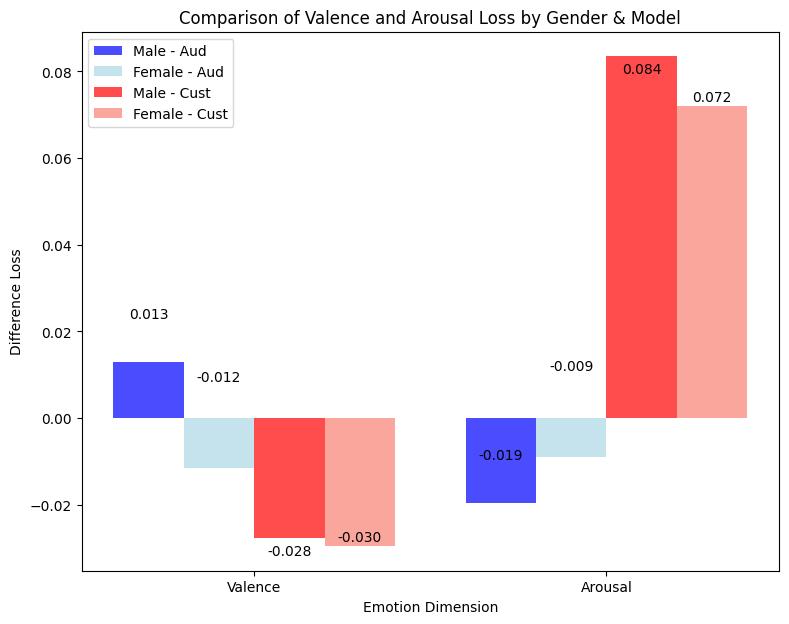

In [10]:
import matplotlib.pyplot as plt


categories = ["Valence", "Arousal"]
male_aud = [male_val_aud, male_ar_aud]
female_aud = [female_val_aud, female_ar_aud]
male_cust = [male_val_cust, male_ar_cust]
female_cust = [female_val_cust, female_ar_cust]

x = np.arange(len(categories))  
width = 0.2  

fig, ax = plt.subplots(figsize=(9, 7))

# Plot bars
ax.bar(x - 1.5 * width, male_aud, width, label="Male - Aud", color="blue", alpha=0.7)
ax.bar(x - 0.5 * width, female_aud, width, label="Female - Aud", color="lightblue", alpha=0.7)
ax.bar(x + 0.5 * width, male_cust, width, label="Male - Cust", color="red", alpha=0.7)
ax.bar(x + 1.5 * width, female_cust, width, label="Female - Cust", color="salmon", alpha=0.7)

# Labels and formatting
ax.set_xlabel("Emotion Dimension")
ax.set_ylabel("Difference Loss")
ax.set_title("Comparison of Valence and Arousal Loss by Gender & Model")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Display values on bars
for i, (m_a, f_a, m_c, f_c) in enumerate(zip(male_aud, female_aud, male_cust, female_cust)):
    ax.text(i - 1.5 * width, m_a + 0.01, f"{m_a:.3f}", ha="center", fontsize=10)
    ax.text(i - 0.5 * width, f_a + 0.02, f"{f_a:.3f}", ha="center", fontsize=10)
    ax.text(i + 0.5 * width, m_c - 0.004, f"{m_c:.3f}", ha="center", fontsize=10)
    ax.text(i + 1.5 * width, f_c + 0.001, f"{f_c:.3f}", ha="center", fontsize=10)

plt.show()

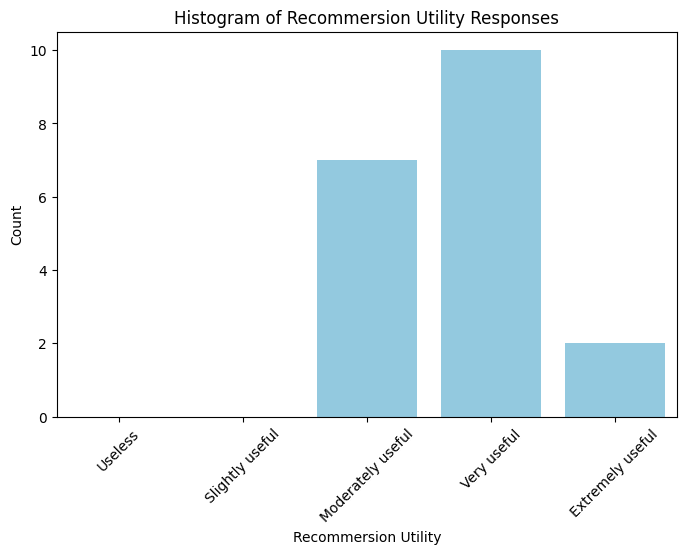

In [12]:
import seaborn as sns

translation_dict = {
    "Inutile": "Useless",
    "Leggermente utile": "Slightly useful",
    "Moderatamente utile": "Moderately useful",
    "Molto utile": "Very useful",
    "Estremamente utile": "Extremely useful"
}

df.columns = df.columns.str.strip()

if "Recommersion_utility" in df.columns:
    df["Recommersion_utility_english"] = df["Recommersion_utility"].map(translation_dict)

categories = ["Useless", "Slightly useful", "Moderately useful", "Very useful", "Extremely useful"]

category_counts = df["Recommersion_utility_english"].value_counts().reindex(categories, fill_value=0)

plt.figure(figsize=(8, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, color="skyblue")


plt.xlabel("Recommersion Utility")
plt.ylabel("Count")
plt.title("Histogram of Recommersion Utility Responses")
plt.xticks(rotation=45)
plt.show()
